# Customer Churn Prediction — Telecom Services

Predicting which telecom customers are likely to cancel their subscription (churn), so the business can step in early with a attractive offers.

## Section 1: Problem & Context

**Why churn matters.** Nowadays most of telecom companies are subscription based and making money so losing a customer isn't just one lost sale it’s about losing their all future payments It's also well known in the industry that it acquire a lot of cost and difficult to get a new customer than an existing customer. So if we can identify customers who are *about to* leave so the retention team can reach out to them with a discounts, offers something more on their current plan or just a support call before they cancel.

**How ML helps.** Instead of waiting for customers to churn we train a model on our previous customer data on people who already churned or stayed to find patterns like which contract types, tenure lengths, or add-on services are reasons why customers moving to other company. Then we use that model to calculate current customers and rank them by churn risk.

**About the data.** We're using the Telco Customer Churn dataset from Kaggle:

https://www.kaggle.com/datasets/blastchar/telco-customer-churn

This is a view of customer’s accounts from a fake telecom company. Each row is one customer with columns describing their demographics (gender, senior citizen status), account info (tenure, contract type, payment method) the services signed up for phone, internet, streaming, tech support, etc and their charges. The target column is Churn which is Yes if the customer left in the last month and No. if they're still a customer. For modelling we'll convert this to 1 (churned) and 0 means stayed.

**The ML task** This is a binary classification problem for each customer predict `Churn = 1` or `Churn = 0`, and ideally also get a probability score so we can rank customers by risk instead of just yes/no.

## Section 2: Data Exploration & Quality Analysis (EDA)

Before doing anything further let's just look at the data how big it is, what types the columns are, and whether it has missing values, weird formatting, etc.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Dataset from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
df = pd.read_csv("file.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# check datatypes and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Right away, `TotalCharges` shows up as an `object` (text) column instead of a number. That's suspicious for a column that should be pure dollars. Let's check for missing values normally first, then dig into why `TotalCharges` isn't numeric.

In [4]:
# standard missing value check - this alone shows 0 missing, which is misleading
print(df.isnull().sum().sum(), "missing values found by isnull()")

# but TotalCharges is stored as text, so let's look for blank/whitespace-only strings
blank_mask = df["TotalCharges"].str.strip() == ""
print(f"\nRows where TotalCharges is just whitespace: {blank_mask.sum()}")
df[blank_mask][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

0 missing values found by isnull()

Rows where TotalCharges is just whitespace: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


So `isnull()` reports zero missing values, but that's only because the missing entries are hidden as blank strings (`" "`) instead of actual NaN. All of these rows turn out to have `tenure = 0`, which makes sense — these are brand new customers who haven't been billed a full cycle yet, so there's no total charge to report. We'll fix this properly in Section 3. For now let's just note it as a data quality issue we found.

Next, let's look at the target variable itself.

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


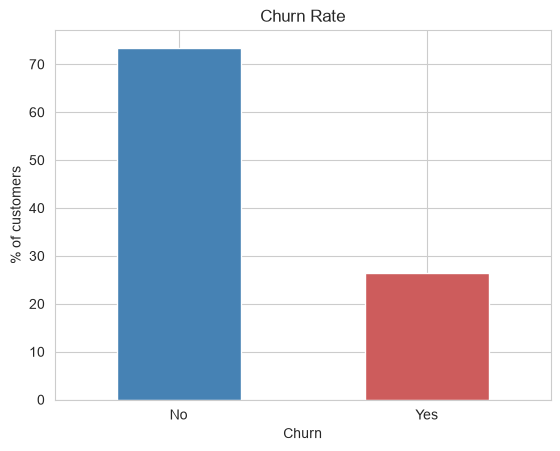

In [5]:
churn_counts = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)

churn_counts.plot(kind="bar", color=["steelblue", "indianred"])
plt.title("Churn Rate")
plt.ylabel("% of customers")
plt.xticks(rotation=0)
plt.show()

About 26% of customers churned and 74% stayed. This is a class imbalance — not extreme, but enough to be careful about.

**Why this matters for choosing metrics:** if we just predicted "No churn" for every single customer, we'd already be ~74% accurate while being completely useless for the actual business goal (finding the people who are about to leave). So plain accuracy is a bad metric here — it hides how the model performs on the minority class we actually care about.

Instead we'll focus on:
- **Recall** (of actual churners, how many did we catch?) — this matters because missing a churner means losing that customer for good.
- **Precision** (of everyone we flagged as a churn risk, how many really were?) — this matters because retention offers cost money, so we don't want to blast discounts at people who were never going to leave.
- **ROC-AUC** — gives an overall sense of how well the model separates churners from non-churners, independent of the threshold we pick.

We'll come back to the precision/recall trade-off in Section 5.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", ax=axes[0])
axes[0].set_title("Tenure (months) vs Churn")

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[1])
axes[1].set_title("Contract Type vs Churn")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

Two patterns jump out right away:

- **Tenure**: churn is heavily concentrated in the first few months. New customers churn a lot; once someone sticks around for 1-2 years, they're much more likely to stay.
- **Contract type**: month-to-month customers churn way more than customers on 1-year or 2-year contracts. That makes intuitive sense — a monthly contract has zero cost to cancel, while a 2-year contract locks people in.

These two features (`tenure` and `Contract`) already look like they'll be strong predictors, which will be useful to keep in mind when we check feature importance later.